# Gráficos para la presentación de avance

In [16]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

carpeta = Path("data") / "processed"

# Lee todos los CSV y los guarda en un diccionario
datasets = {
    archivo.stem: pd.read_csv(archivo)
    for archivo in carpeta.glob("*.csv")
}

# Accede a cada DataFrame por su nombre
df_ccp = datasets["dataset_entrenamiento_ccp"]
df_stgo = datasets["dataset_entrenamiento_stgo"]
dataframes  = [df_ccp, df_stgo]
display(df_ccp)
display(df_stgo)

,id_celda,target_supermercado,conteo_paraderos,conteo_convenience,conteo_mall,conteo_pharmacy,conteo_marketplace,conteo_school,conteo_university,conteo_college,conteo_hospital,conteo_clinic,conteo_sports_centre,densidad_poblacion
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0
2,2,0,0,0,0,0,0,0,0,0,0,0,0,525.0
3,3,0,0,0,0,0,0,0,0,0,0,0,0,752.0
4,4,0,0,0,0,0,0,0,0,0,0,0,0,673.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10496,10496,0,0,0,0,0,0,0,0,0,0,0,0,0.0
10497,10497,0,0,0,0,0,0,0,0,0,0,0,0,0.0
10498,10498,0,0,0,0,0,0,0,0,0,0,0,0,0.0
10499,10499,0,0,0,0,0,0,0,0,0,0,0,0,0.0


,id_celda,target_supermercado,conteo_paraderos,conteo_convenience,conteo_mall,conteo_pharmacy,conteo_marketplace,conteo_school,conteo_university,conteo_college,conteo_hospital,conteo_clinic,conteo_sports_centre,densidad_poblacion
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0
2,2,0,0,0,0,0,0,0,0,0,0,0,0,0.0
3,3,0,0,0,0,0,0,0,0,0,0,0,0,0.0
4,4,0,0,0,0,0,0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148906,148906,0,0,0,0,0,0,0,0,0,0,0,0,0.0
148907,148907,0,0,0,0,0,0,0,0,0,0,0,0,0.0
148908,148908,0,0,0,0,0,0,0,0,0,0,0,0,0.0
148909,148909,0,0,0,0,0,0,0,0,0,0,0,0,0.0


## 1. Matriz de Correlación de Variables Clave (Heatmap)
Para evitar un gráfico saturado en la presentación, este código selecciona los atractores comerciales y demográficos más relevantes frente a la variable objetivo. Permite justificar qué características de la celda influyen más en la decisión del modelo.

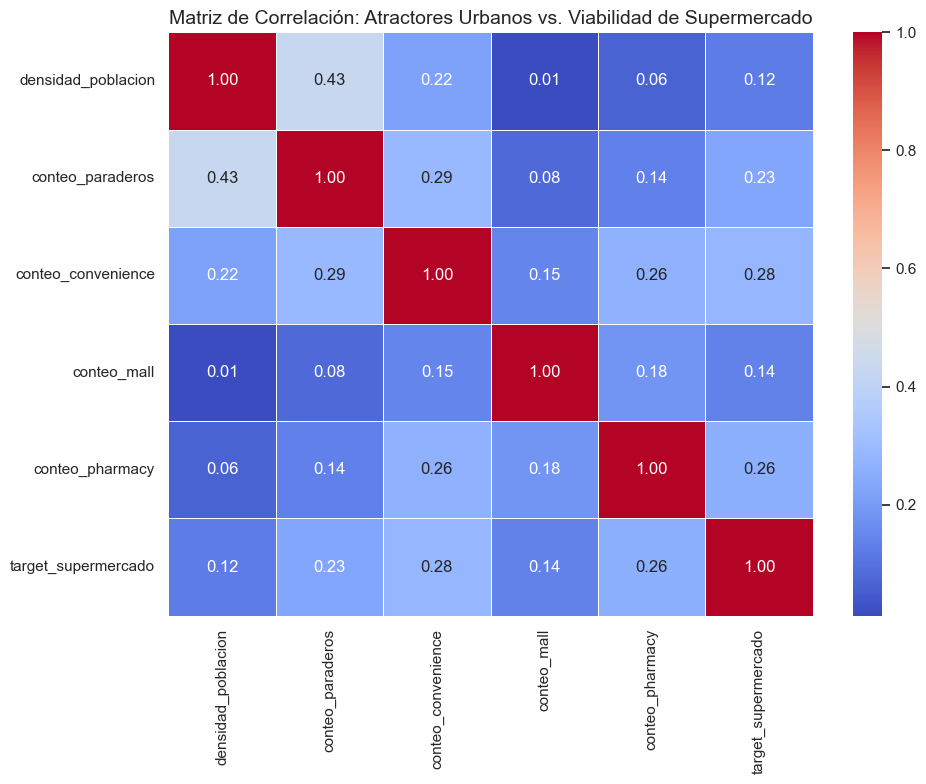

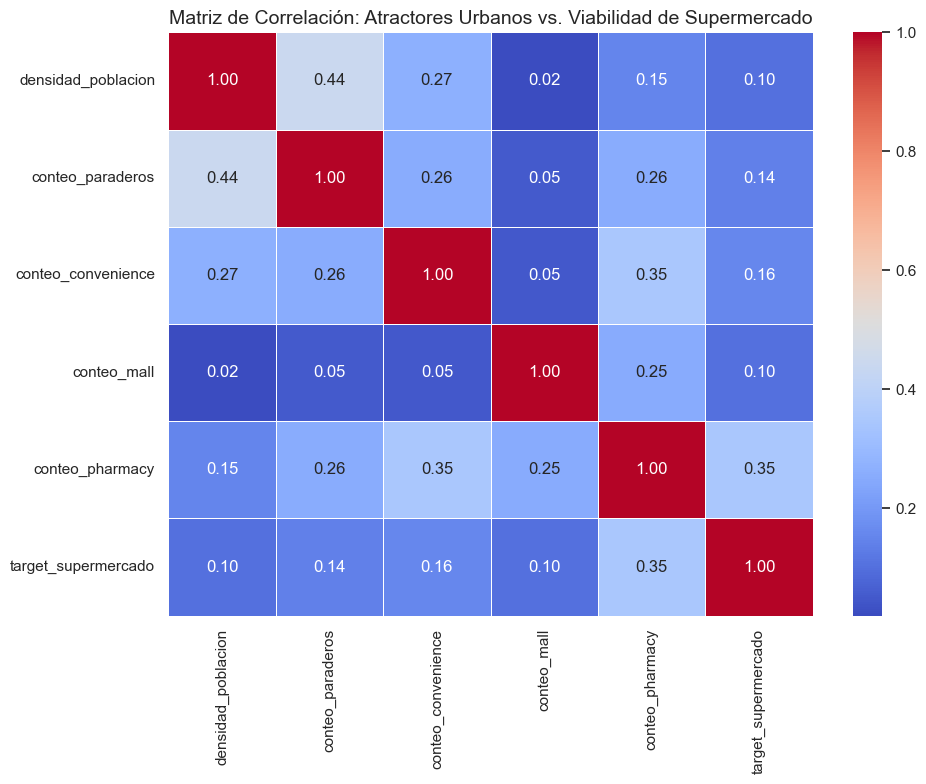

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


for df in dataframes:
    # Selección de las columnas más representativas para la presentación
    columnas_analisis = [
        'densidad_poblacion', 
        'conteo_paraderos', 
        'conteo_convenience', 
        'conteo_mall', 
        'conteo_pharmacy', 
        'target_supermercado'
    ]
    df_analisis = df[columnas_analisis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(df_analisis.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Matriz de Correlación: Atractores Urbanos vs. Viabilidad de Supermercado', fontsize=14)
    plt.tight_layout()
    plt.show()

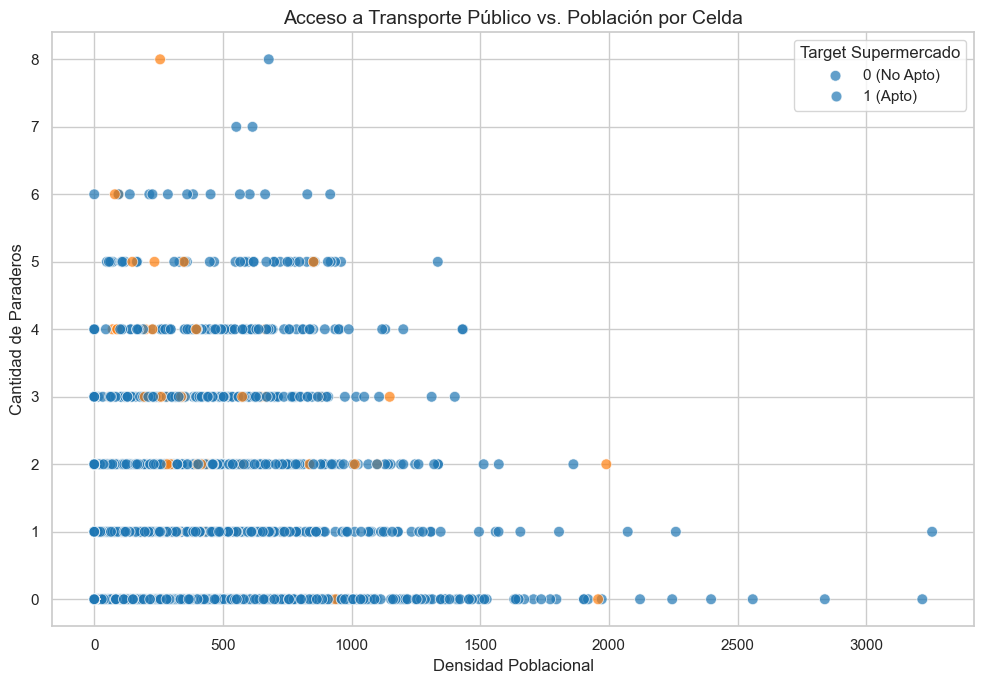

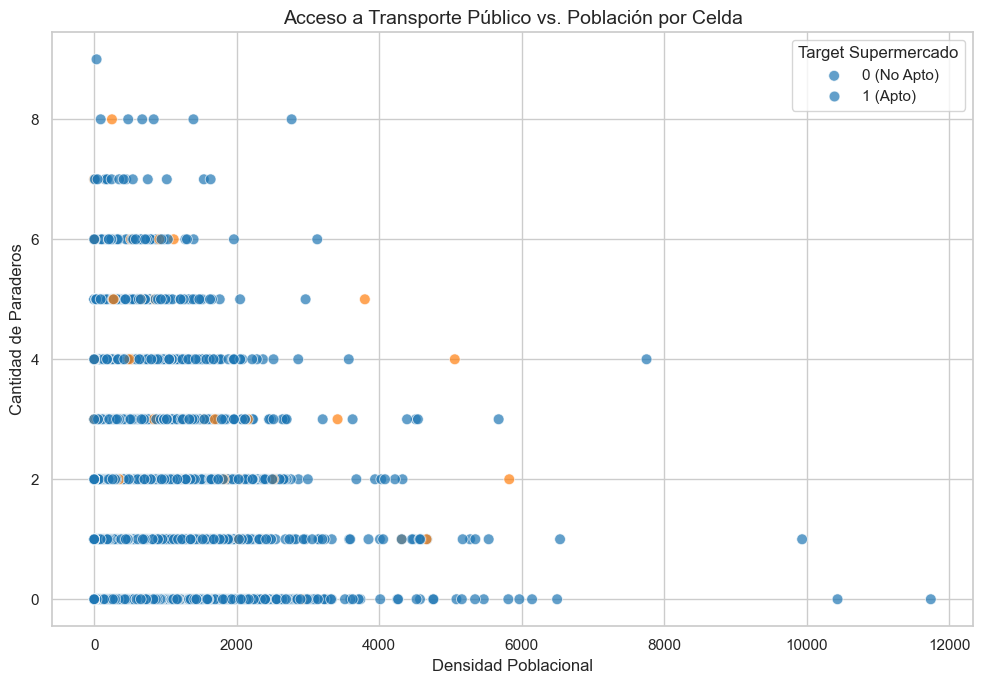

In [18]:
for df in dataframes:
    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x='densidad_poblacion', 
        y='conteo_paraderos', 
        hue='target_supermercado', 
        palette=['#1f77b4', '#ff7f0e'], 
        data=df, 
        alpha=0.7, 
        s=60
    )

    plt.title('Acceso a Transporte Público vs. Población por Celda', fontsize=14)
    plt.xlabel('Densidad Poblacional', fontsize=12)
    plt.ylabel('Cantidad de Paraderos', fontsize=12)

    plt.legend(title='Target Supermercado', labels=['0 (No Apto)', '1 (Apto)'])
    plt.tight_layout()
    plt.show()

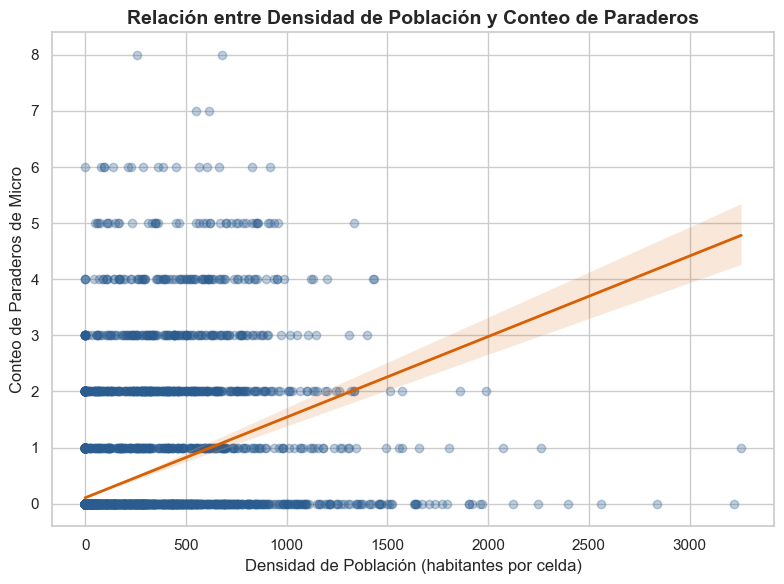

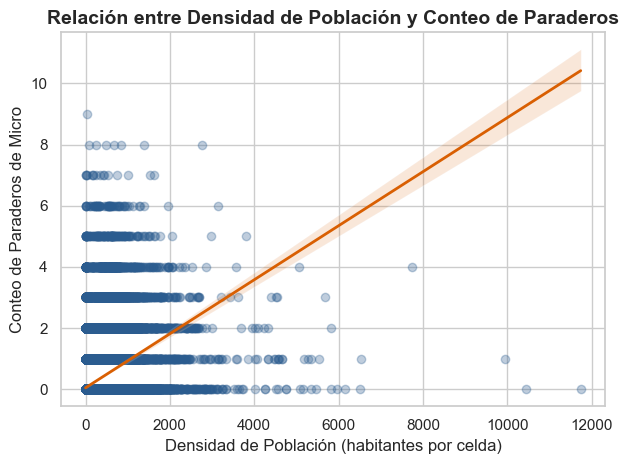

In [19]:

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

for df in dataframes:
    # Gráfico de dispersión con tendencia (regresión lineal simple)
    sns.regplot(
        data=df, 
        x='densidad_poblacion', 
        y='conteo_paraderos',
        scatter_kws={'alpha': 0.3, 'color': '#2b5c8f'},
    line_kws={'color': '#d95f02', 'linewidth': 2}
    )

    plt.title('Relación entre Densidad de Población y Conteo de Paraderos', fontsize=14, fontweight='bold')
    plt.xlabel('Densidad de Población (habitantes por celda)', fontsize=12)
    plt.ylabel('Conteo de Paraderos de Micro', fontsize=12)

    plt.tight_layout()
    plt.show()

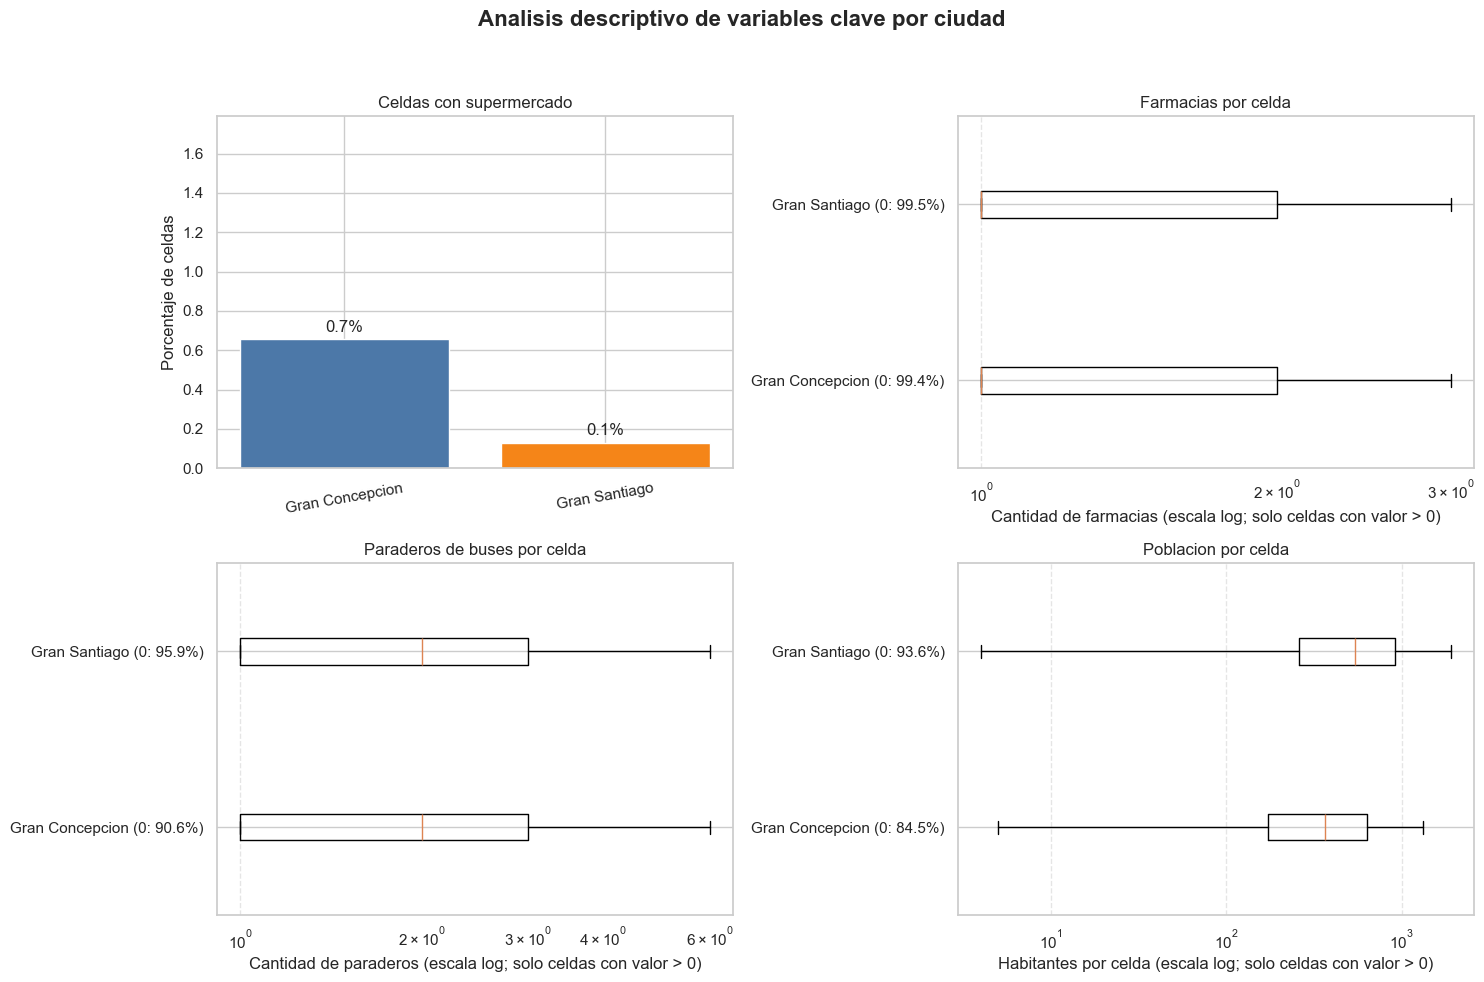

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

ciudades = {
    "Gran Concepcion": df_ccp,
    "Gran Santiago": df_stgo,
}
columnas = [
    "target_supermercado",
    "conteo_pharmacy",
    "conteo_paraderos",
    "densidad_poblacion",
]

for ciudad, datos in ciudades.items():
    faltantes = [columna for columna in columnas if columna not in datos.columns]
    if faltantes:
        raise KeyError(f"Faltan columnas en {ciudad}: {faltantes}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Analisis descriptivo de variables clave por ciudad", fontsize=16, fontweight="bold")

# Porcentaje de celdas con supermercado.
porcentajes = [
    ciudades[ciudad]["target_supermercado"].eq(1).mean() * 100
    for ciudad in ciudades
]
barras = axes[0, 0].bar(
    list(ciudades.keys()),
    porcentajes,
    color=["#4c78a8", "#f58518"],
)
axes[0, 0].bar_label(barras, fmt="%.1f%%", padding=3)
axes[0, 0].set_ylim(0, max(porcentajes, default=0) * 1.2 + 1)
axes[0, 0].set_title("Celdas con supermercado")
axes[0, 0].set_ylabel("Porcentaje de celdas")
axes[0, 0].tick_params(axis="x", rotation=10)

# Se muestran las distribuciones positivas en escala log para hacer visible
# la mayor parte de los valores en estas variables sesgadas.
for ax, columna, titulo, etiqueta_x in [
    (axes[0, 1], "conteo_pharmacy", "Farmacias por celda", "Cantidad de farmacias"),
    (axes[1, 0], "conteo_paraderos", "Paraderos de buses por celda", "Cantidad de paraderos"),
    (axes[1, 1], "densidad_poblacion", "Poblacion por celda", "Habitantes por celda"),
]:
    valores_positivos = []
    etiquetas = []
    for ciudad, datos in ciudades.items():
        valores = pd.to_numeric(datos[columna], errors="raise").dropna()
        positivos = valores[valores > 0]
        if positivos.empty:
            raise ValueError(f"No hay valores positivos para {titulo.lower()} en {ciudad}.")
        porcentaje_cero = valores.eq(0).mean() * 100
        valores_positivos.append(positivos)
        etiquetas.append(f"{ciudad} (0: {porcentaje_cero:.1f}%)")

    ax.boxplot(valores_positivos, vert=False, tick_labels=etiquetas, showfliers=False)
    ax.set_xscale("log")
    ax.set_title(titulo)
    ax.set_xlabel(f"{etiqueta_x} (escala log; solo celdas con valor > 0)")
    ax.grid(axis="x", linestyle="--", alpha=0.5)

fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

C:\Users\Mateo Jr\AppData\Local\Temp\ipykernel_7596\1755615790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_supermercado', y=col, palette='Set2')


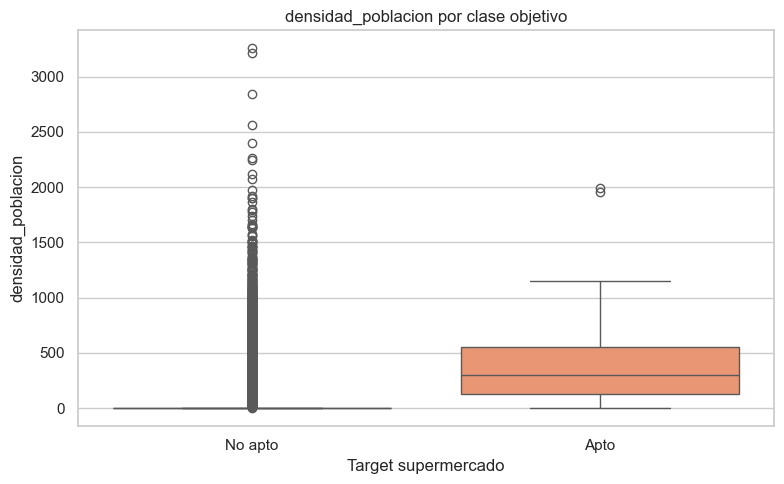

C:\Users\Mateo Jr\AppData\Local\Temp\ipykernel_7596\1755615790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_supermercado', y=col, palette='Set2')


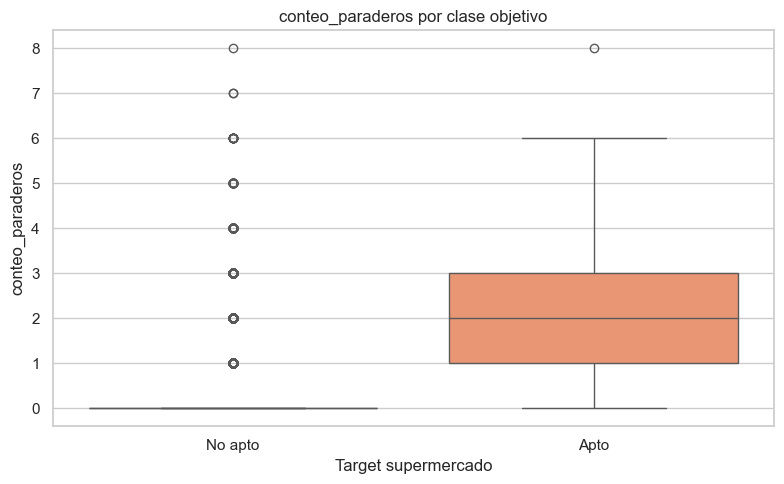

C:\Users\Mateo Jr\AppData\Local\Temp\ipykernel_7596\1755615790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_supermercado', y=col, palette='Set2')


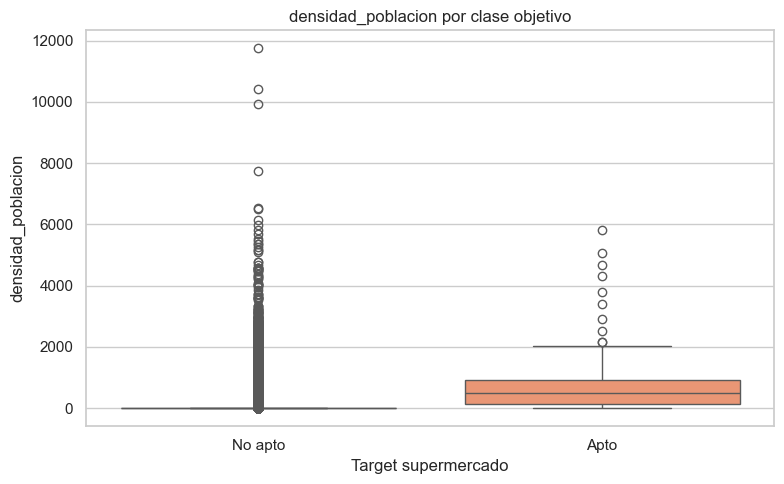

C:\Users\Mateo Jr\AppData\Local\Temp\ipykernel_7596\1755615790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_supermercado', y=col, palette='Set2')


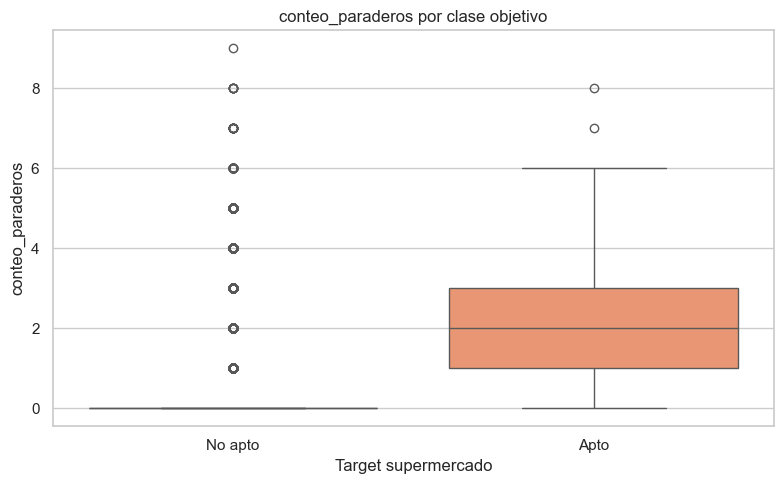

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Boxplot por clase
cols = ['densidad_poblacion', 'conteo_paraderos', 'distancia_centro']
for df in dataframes:
    for col in cols:
        if col in df.columns:
            plt.figure(figsize=(8, 5))
            sns.boxplot(data=df, x='target_supermercado', y=col, palette='Set2')
            plt.title(f'{col} por clase objetivo')
            plt.xlabel('Target supermercado')
            plt.ylabel(col)
            plt.xticks([0, 1], ['No apto', 'Apto'])
            plt.tight_layout()
            plt.show()

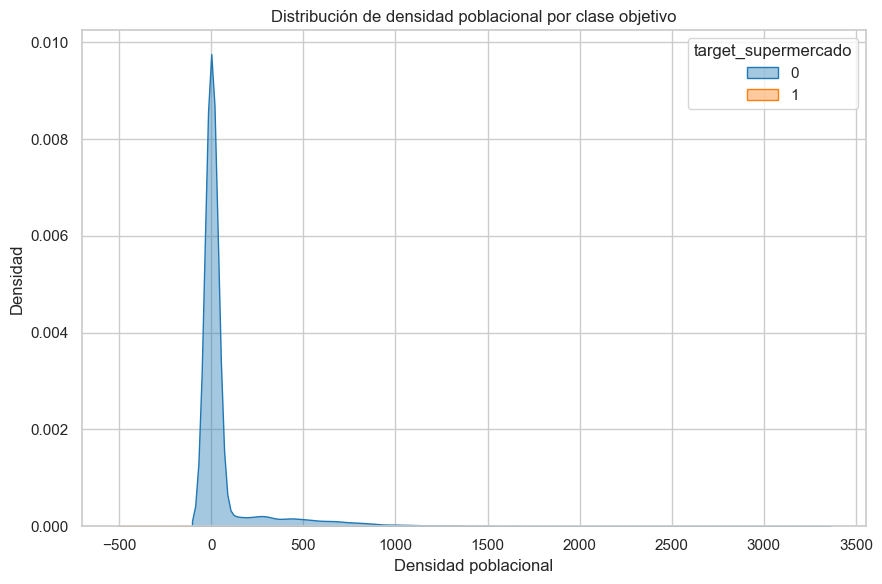

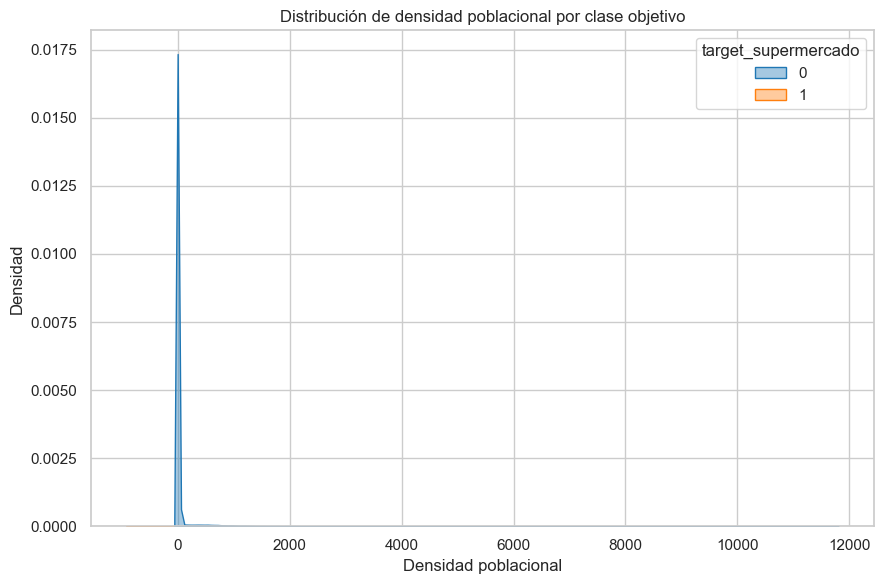

In [22]:
for df in dataframes:
    # 3) Histograma / KDE por clase
    plt.figure(figsize=(9, 6))
    sns.kdeplot(data=df, x='densidad_poblacion', hue='target_supermercado',
                palette=['#1f77b4', '#ff7f0e'], fill=True, alpha=0.4)
    plt.title('Distribución de densidad poblacional por clase objetivo')
    plt.xlabel('Densidad poblacional')
    plt.ylabel('Densidad')
    plt.tight_layout()
    plt.show()

In [24]:
vars_interes = ['farmacias', 'paraderos', 'malls', 'poblacion', 'almacenes', 'colegios', 'hospitales']

for df in dataframes:
    for col in vars_interes:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df, x='target_supermercado', y=col, palette='Set2')
        plt.title(f'{col} por clase objetivo')
        plt.xlabel('Target Supermercado')
        plt.ylabel(col)
        plt.xticks([0, 1], ['No apto', 'Apto'])
        plt.tight_layout()
        plt.show()

ValueError: Could not interpret value `farmacias` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

Gran Santiago: 148,911 celdas totales | 9,599 pobladas (6.4%) | tasa de supermercado: 0.13% sobre todas, 1.71% sobre pobladas
Gran Concepción: 10,501 celdas totales | 1,630 pobladas (15.5%) | tasa de supermercado: 0.66% sobre todas, 3.87% sobre pobladas


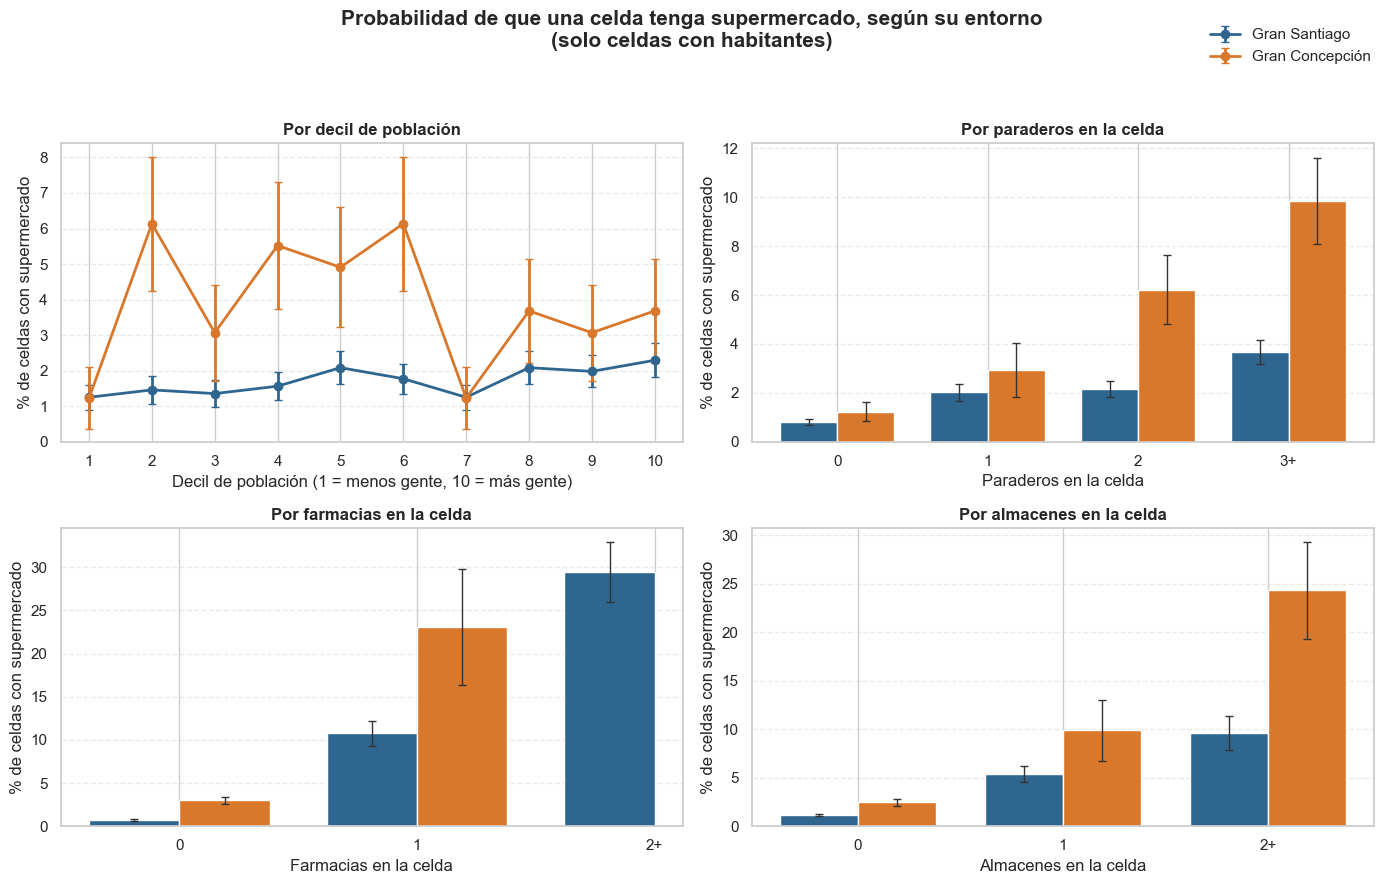


### Gran Santiago: tasa de supermercado por decil de población
       habitantes_desde  habitantes_hasta  celdas  con_supermercado_%
decil                                                                
1                     4                97     960                1.25
2                    97               204     960                1.46
3                   204               318     960                1.35
4                   318               429     960                1.56
5                   429               541     960                2.08
6                   542               668     959                1.77
7                   668               820     960                1.25
8                   820              1020     960                2.08
9                  1020              1363     960                1.98
10                 1363             11743     960                2.29
Lectura: el decil más poblado tiene 1.8 veces más probabilidad que el menos poblado (2.29 % cont

In [26]:
# =============================================================================
# Análisis bivariado: ¿cómo cambia la probabilidad de tener supermercado
# según el nivel de cada variable?
#
# Pegar como una celda nueva al final de 01_spatial_data_processing.ipynb.
# Solo lee los CSV de data/processed, no modifica nada.
#
# Por qué sirve: la correlación de Pearson subestima la relación cuando el
# 99 % de las celdas son cero. Esto muestra la tasa real de positivos por
# nivel, que es lo que un modelo de clasificación va a aprovechar.
# =============================================================================

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ruta_processed = os.path.join("data", "processed")
ruta_figuras = os.path.join("resultados", "bivariado_02")
os.makedirs(ruta_figuras, exist_ok=True)

ARCHIVOS = {
    "Gran Santiago": "dataset_entrenamiento_stgo.csv",
    "Gran Concepción": "dataset_entrenamiento_ccp.csv",
}
COLOR_CIUDAD = {"Gran Santiago": "#2F6690", "Gran Concepción": "#D9772B"}

# Mínimo de celdas para que un grupo se grafique. Con menos, la tasa es ruido.
N_MINIMO = 30

# -----------------------------------------------------------------------------
# 1. Cargar y quedarse SOLO con celdas pobladas
# -----------------------------------------------------------------------------
datos = {}
for ciudad, archivo in ARCHIVOS.items():
    ruta = os.path.join(ruta_processed, archivo)
    if not os.path.isfile(ruta):
        raise FileNotFoundError(f"No se encontró {ruta}")
    completo = pd.read_csv(ruta)
    poblado = completo[completo["densidad_poblacion"] > 0].copy()
    datos[ciudad] = poblado
    print(
        f"{ciudad}: {len(completo):,} celdas totales | "
        f"{len(poblado):,} pobladas ({len(poblado) / len(completo):.1%}) | "
        f"tasa de supermercado: {completo['target_supermercado'].mean():.2%} "
        f"sobre todas, {poblado['target_supermercado'].mean():.2%} sobre pobladas"
    )


def resumir(df, col_grupo):
    """Por grupo: cuántas celdas hay, qué % tiene supermercado y su error estándar.

    El error estándar sirve para no leer como diferencia algo que es ruido:
    si dos barras se solapan, no se pueden distinguir con estos datos.
    """
    g = df.groupby(col_grupo, observed=True)["target_supermercado"]
    out = g.agg(n="size", p="mean")
    out["pct"] = 100 * out["p"]
    out["ee"] = 100 * np.sqrt(out["p"] * (1 - out["p"]) / out["n"])
    return out[["n", "pct", "ee"]]


# -----------------------------------------------------------------------------
# 2. Panel A: población en deciles
# -----------------------------------------------------------------------------
def tasa_por_decil(df, n_grupos=10):
    """Divide las celdas pobladas en grupos de igual tamaño según población."""
    df = df.copy()
    # Se ordena por rango y no por valor: muchas celdas comparten el mismo
    # número de habitantes y los cortes quedarían pegados.
    df["grupo"] = pd.qcut(
        df["densidad_poblacion"].rank(method="first"),
        n_grupos,
        labels=False,
        duplicates="drop",
    )
    resumen = resumir(df, "grupo")
    rangos = df.groupby("grupo", observed=True)["densidad_poblacion"].agg(["min", "max"])
    return resumen.join(rangos)


# -----------------------------------------------------------------------------
# 3. Paneles B, C, D: variables de conteo, agrupadas por su valor
# -----------------------------------------------------------------------------
def etiquetas_conteo(tope):
    """Etiquetas comunes del eje X: 0, 1, ..., tope+."""
    return [str(v) if v < tope else f"{v}+" for v in range(tope + 1)]


def tasa_por_conteo(df, columna, tope=3):
    """Agrupa por el valor del conteo; todo lo mayor o igual al tope se junta.

    Devuelve siempre las mismas filas (0, 1, ..., tope+) aunque alguna no
    tenga celdas, para que las dos ciudades compartan el mismo eje X.
    """
    df = df.copy()
    df["grupo"] = df[columna].clip(upper=tope)
    resumen = resumir(df, "grupo").reindex(range(tope + 1))
    resumen.index = etiquetas_conteo(tope)
    return resumen


# -----------------------------------------------------------------------------
# 4. Figura 2 x 2
# -----------------------------------------------------------------------------
PANELES_CONTEO = [
    ("conteo_paraderos", "Paraderos en la celda", 3),
    ("conteo_pharmacy", "Farmacias en la celda", 2),
    ("conteo_convenience", "Almacenes en la celda", 2),
]

fig, ejes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Probabilidad de que una celda tenga supermercado, según su entorno\n"
    "(solo celdas con habitantes)",
    fontsize=15,
    fontweight="bold",
)

# --- Panel A: población ---
ax = ejes[0, 0]
tablas_decil = {}
for ciudad, df in datos.items():
    t = tasa_por_decil(df)
    tablas_decil[ciudad] = t
    visible = t[t["n"] >= N_MINIMO]
    ax.errorbar(
        visible.index + 1,
        visible["pct"],
        yerr=visible["ee"],
        marker="o",
        capsize=3,
        linewidth=2,
        color=COLOR_CIUDAD[ciudad],
        label=ciudad,
    )
ax.set_title("Por decil de población", fontsize=12, fontweight="bold")
ax.set_xlabel("Decil de población (1 = menos gente, 10 = más gente)")
ax.set_ylabel("% de celdas con supermercado")
ax.set_xticks(range(1, 11))
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# --- Paneles B, C, D: conteos ---
for eje, (columna, titulo, tope) in zip(
    [ejes[0, 1], ejes[1, 0], ejes[1, 1]], PANELES_CONTEO
):
    if not all(columna in df.columns for df in datos.values()):
        eje.set_visible(False)
        continue
    etiquetas = etiquetas_conteo(tope)
    posiciones_base = np.arange(len(etiquetas))
    ancho = 0.38
    for i, (ciudad, df) in enumerate(datos.items()):
        t = tasa_por_conteo(df, columna, tope=tope)
        # Un grupo con pocas celdas da una tasa que es puro ruido: no se dibuja.
        alturas = t["pct"].where(t["n"] >= N_MINIMO)
        errores = t["ee"].where(t["n"] >= N_MINIMO)
        posiciones = posiciones_base + (i - 0.5) * ancho
        eje.bar(
            posiciones,
            alturas,
            width=ancho,
            color=COLOR_CIUDAD[ciudad],
            label=ciudad,
        )
        eje.errorbar(
            posiciones,
            alturas,
            yerr=errores,
            fmt="none",
            ecolor="#333333",
            capsize=3,
            linewidth=1,
        )
    # Los ticks se fijan UNA vez, fuera del bucle de ciudades: si una ciudad
    # tiene menos grupos que la otra, las etiquetas igual quedan alineadas.
    eje.set_xticks(posiciones_base)
    eje.set_xticklabels(etiquetas)
    eje.set_title(f"Por {titulo.lower()}", fontsize=12, fontweight="bold")
    eje.set_xlabel(titulo)
    eje.set_ylabel("% de celdas con supermercado")
    eje.set_ylim(bottom=0)
    eje.grid(axis="y", linestyle="--", alpha=0.4)

manijas, nombres = ax.get_legend_handles_labels()
fig.legend(
    manijas,
    nombres,
    loc="upper right",
    bbox_to_anchor=(0.995, 0.975),
    frameon=False,
    fontsize=11,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(os.path.join(ruta_figuras, "tasa_por_nivel.svg"), bbox_inches="tight")
fig.savefig(
    os.path.join(ruta_figuras, "tasa_por_nivel.png"), dpi=400, bbox_inches="tight"
)
plt.show()

# -----------------------------------------------------------------------------
# 5. Tablas con los números, para citarlos en la presentación
# -----------------------------------------------------------------------------
for ciudad, t in tablas_decil.items():
    print(f"\n### {ciudad}: tasa de supermercado por decil de población")
    tabla = pd.DataFrame(
        {
            "decil": t.index + 1,
            "habitantes_desde": t["min"].astype(int),
            "habitantes_hasta": t["max"].astype(int),
            "celdas": t["n"].astype(int),
            "con_supermercado_%": t["pct"].round(2),
        }
    ).set_index("decil")
    print(tabla.to_string())

    primero, ultimo = t["pct"].iloc[0], t["pct"].iloc[-1]
    if primero > 0:
        print(
            f"Lectura: el decil más poblado tiene {ultimo / primero:.1f} veces "
            f"más probabilidad que el menos poblado "
            f"({ultimo:.2f} % contra {primero:.2f} %)."
        )
    else:
        print(
            f"Lectura: el decil menos poblado no tiene ninguna celda con "
            f"supermercado; el más poblado llega a {ultimo:.2f} %."
        )

for columna, titulo, tope in PANELES_CONTEO:
    if not all(columna in df.columns for df in datos.values()):
        continue
    print(f"\n### Tasa de supermercado por {titulo.lower()}")
    for ciudad, df in datos.items():
        t = tasa_por_conteo(df, columna, tope=tope)
        resumen = ", ".join(
            f"{idx}: {fila['pct']:.1f} % (n={int(fila['n']):,})"
            for idx, fila in t.iterrows()
            if pd.notna(fila["n"]) and fila["n"] >= N_MINIMO
        )
        print(f"{ciudad} -> {resumen}")

In [28]:
import pandas as pd
d = pd.read_csv("data/processed/dataset_entrenamiento_stgo.csv")
print(len(d), d["target_supermercado"].sum())

148911 195


In [29]:
c = pd.read_csv("data/processed/dataset_entrenamiento_ccp.csv")
print(len(c), c["target_supermercado"].sum())

10501 69
